In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

#### Show teams' standard deviation ranking

In [9]:
load_dotenv()
database_url = os.getenv('DATABASE_URL')

engine = create_engine(database_url)

ranking_stdev_df = pd.read_sql('''
                SELECT
                    t.full_name AS team_name,
                    g.year,
                    STDDEV(g.ranking) AS ranking_stdev
                FROM (
                        SELECT
                            year,
                            id_home_team AS team_id,
                            home_team_ranking AS ranking
                        FROM
                            games
                        WHERE
                        home_team_ranking != -1
                    UNION ALL
                        SELECT
                            year,
                            id_away_team AS team_id,
                            away_team_ranking AS ranking
                        FROM
                            games
                        WHERE
                            away_team_ranking != -1
                ) AS g
                JOIN
                    teams AS t ON g.team_id = t.team_id
                GROUP BY
                    t.full_name,
                    g.year
                HAVING
                    COUNT(g.ranking) >= 2
                ORDER BY
                t.full_name,
                g.year;'''
                , engine)

print(ranking_stdev_df)

              team_name  year  ranking_stdev
0     Air Force Falcons  1958       2.768875
1     Air Force Falcons  1959       0.577350
2     Air Force Falcons  1969       0.577350
3     Air Force Falcons  1970       3.973396
4     Air Force Falcons  1971       1.414214
...                 ...   ...            ...
2705      Yale Bulldogs  1937       4.082483
2706      Yale Bulldogs  1944       1.414214
2707      Yale Bulldogs  1946       3.000000
2708      Yale Bulldogs  1959       4.242641
2709      Yale Bulldogs  1960       2.081666

[2710 rows x 3 columns]


#### Show which teams have the most top five wins

In [10]:
top_five_teams_count_df = pd.read_sql('''
    SELECT
        t.full_name AS team_name,
        COUNT(*) as top_five_wins
    FROM
        (SELECT
            year,
            id_home_team AS team_id,
            home_team_ranking AS ranking
        FROM
            games
        WHERE
            home_team_ranking >= 1 AND home_team_ranking <=5
        UNION ALL
        SELECT
            year,
            id_away_team AS team_id,
            away_team_ranking AS ranking
        FROM
            games
        WHERE
            away_team_ranking >= 1 AND away_team_ranking <=5
        ) as g
    JOIN teams as t ON g.team_id = t.team_id
    GROUP BY
        t.full_name
    ORDER BY
        COUNT(*) DESC
                                      ''', engine)

print(top_five_teams_count_df)

                      team_name  top_five_wins
0          Alabama Crimson Tide            372
1              Oklahoma Sooners            327
2           Ohio State Buckeyes            318
3          Nebraska Cornhuskers            239
4   Southern California Trojans            232
..                          ...            ...
79      Saint Mary's (CA) Gaels              1
80                Yale Bulldogs              1
81       Tulsa Golden Hurricane              1
82               Duquesne Dukes              1
83         Oregon State Beavers              1

[84 rows x 2 columns]


### Correlation
#### Visualize the correlation between the win percentage and point differential, using the team and year as the composit key

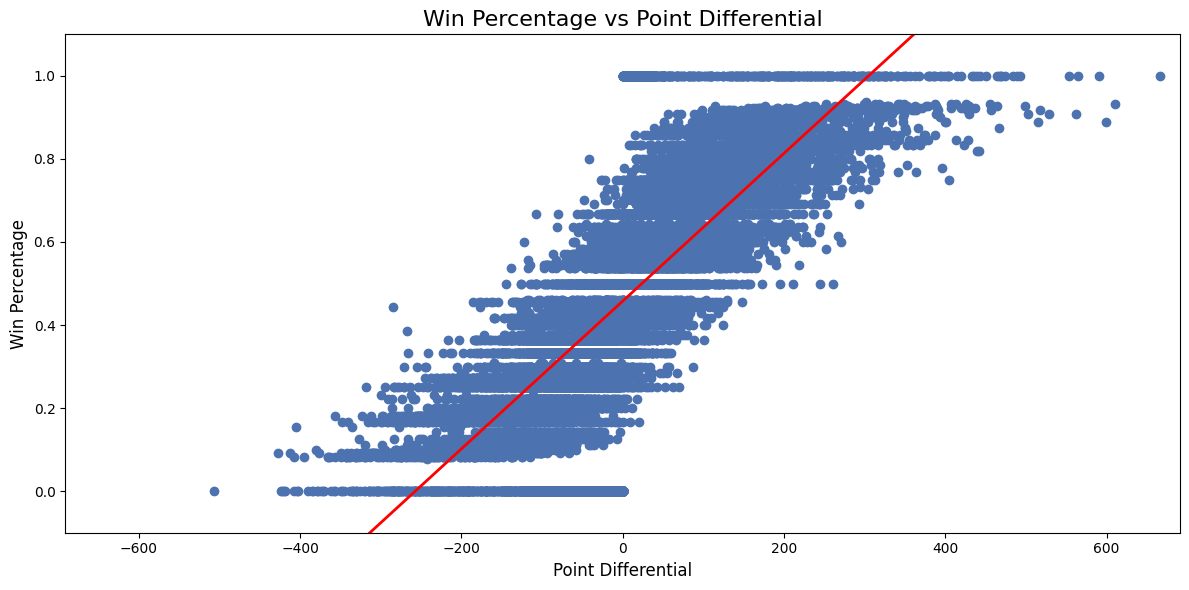

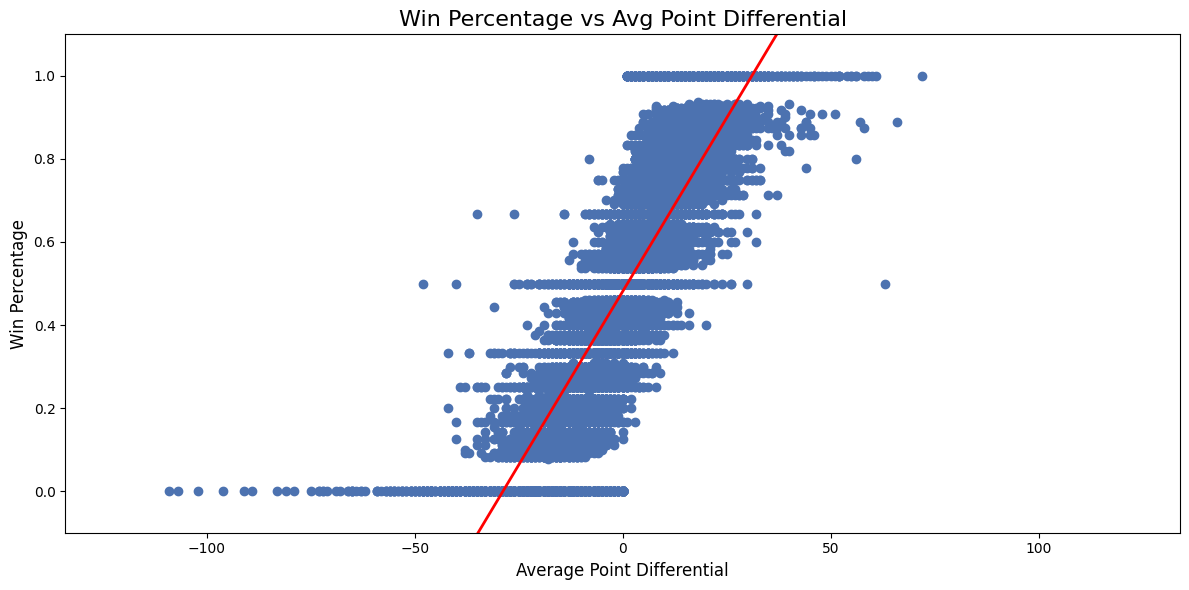

In [11]:
# Raw point differential query
my_df = pd.read_sql(
    """
    select year, team_id, 
           win_percentage / 100.0 as win_percentage, 
           point_differential
    from yearly_team;
    """,
    engine
)

# Average point differential query
my_df_avg = pd.read_sql(
    """
    select year, team_id,
           win_percentage / 100.0 as win_percentage,
           point_differential / (wins + ties + loses) as avg_point_differential
    from yearly_team;
    """,
    engine
)

# Scale for raw differential
min_raw = my_df['point_differential'].min()
max_raw = my_df['point_differential'].max()
raw_scale = max(abs(min_raw), abs(max_raw)) + 25

# Scale for avg differential
min_avg = my_df_avg['avg_point_differential'].min()
max_avg = my_df_avg['avg_point_differential'].max()
avg_scale = max(abs(min_avg), abs(max_avg)) + 25

# FIGURE 1 — Raw point differential
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-deep')

x = my_df['point_differential']
y = my_df['win_percentage']
plt.scatter(x,y)

# Regression line
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2)

plt.xlim(-raw_scale, raw_scale)
plt.ylim(my_df['win_percentage'].min() - .1, my_df['win_percentage'].max() + .1)

plt.xlabel('Point Differential', fontsize=12)
plt.ylabel('Win Percentage', fontsize=12)
plt.title('Win Percentage vs Point Differential', fontsize=16)

plt.tight_layout()
plt.show()

#  FIGURE 2 — Average point differential (PD per game)
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-deep')

x = my_df_avg['avg_point_differential']
y = my_df_avg['win_percentage']

plt.scatter(x, y)

# Regression line
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2)

plt.xlim(-avg_scale, avg_scale)
plt.ylim(my_df['win_percentage'].min() - .1, my_df['win_percentage'].max() + .1)


plt.xlabel('Average Point Differential', fontsize=12)
plt.ylabel('Win Percentage', fontsize=12)
plt.title('Win Percentage vs Avg Point Differential', fontsize=16)

plt.tight_layout()
plt.show()

### Calulations and Visualizations
#### Display the teams which have the most appearances in the Top 5 of the AP poll

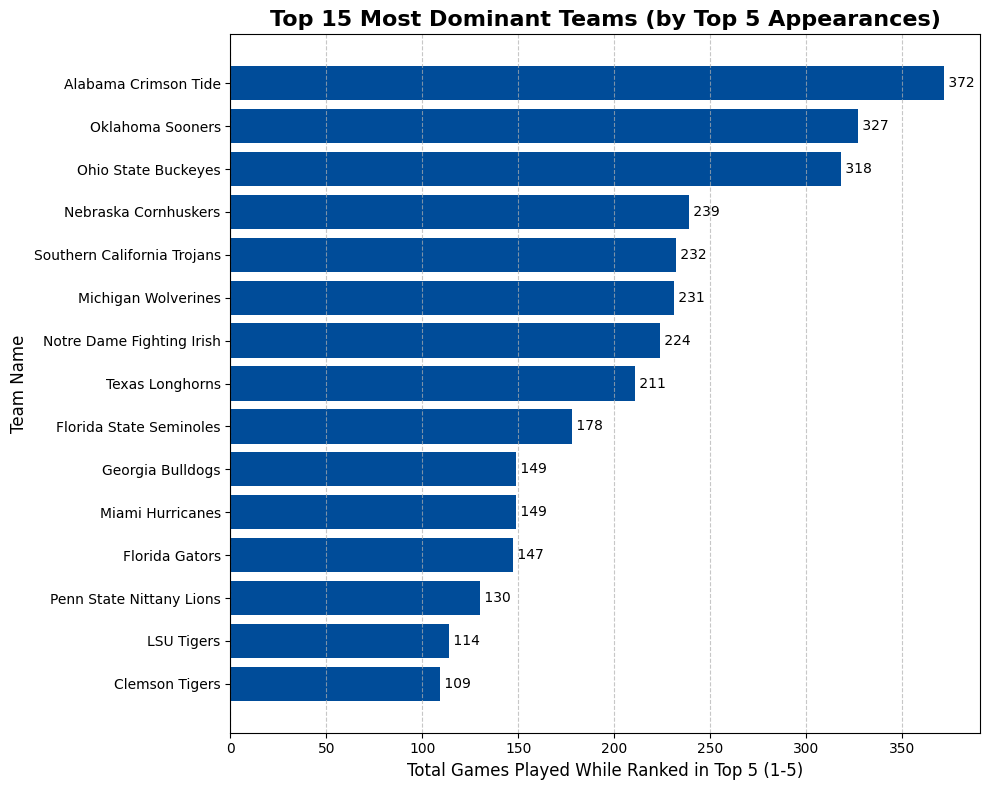

In [12]:
top_five_teams_count_df = top_five_teams_count_df.sort_values(by='top_five_wins', ascending=False).reset_index(drop=True)
top_5_team_names = top_five_teams_count_df['team_name'].head(5).tolist()
top_2_team_names = top_five_teams_count_df['team_name'].head(2).tolist()

top_15_teams_df = top_five_teams_count_df.head(15)

plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-deep') # Using a clean style

plt.barh(top_15_teams_df['team_name'], top_15_teams_df['top_five_wins'], color='#004C99')

# Adding labels and title
plt.xlabel('Total Games Played While Ranked in Top 5 (1-5)', fontsize=12)
plt.ylabel('Team Name', fontsize=12)
plt.title('Top 15 Most Dominant Teams (by Top 5 Appearances)', fontsize=16, fontweight='bold')

# Customize ticks and grid
plt.gca().invert_yaxis() # Display the highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the bars
for index, value in enumerate(top_15_teams_df['top_five_wins']):
    plt.text(value, index, f' {value}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Change in total win percentage by year for 8 Texas Teams

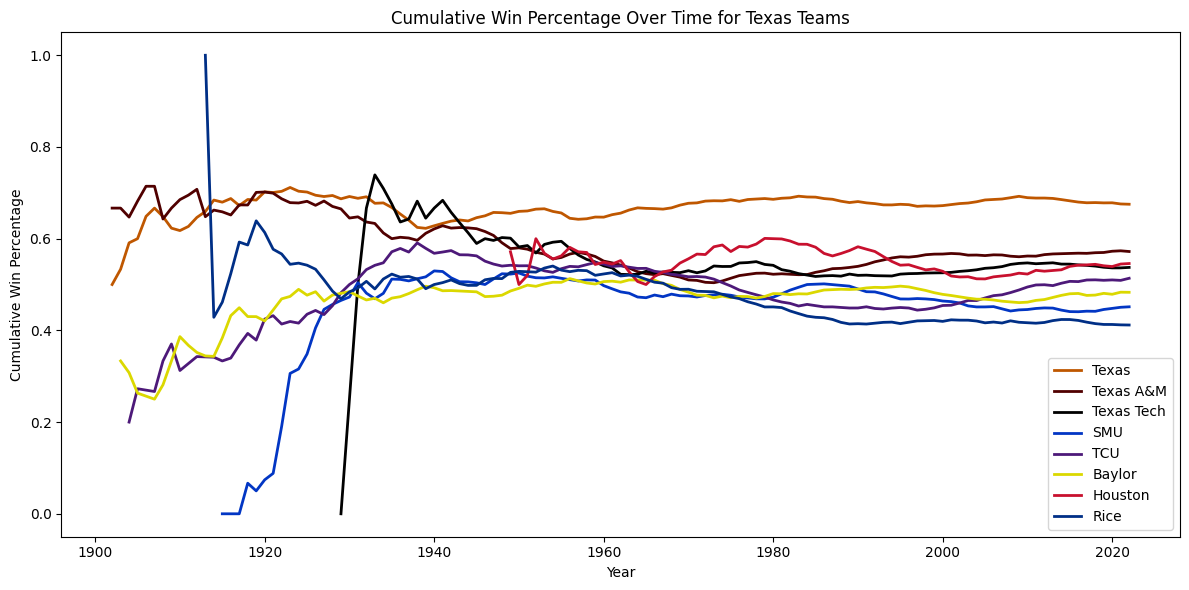

In [13]:
texas_df = pd.read_sql(
    """
select year, t.school_name, y.wins, y.wins + y.ties + y.loses as total_games
from yearly_team y
join teams t on t.team_id = y.team_id;
    """,
    engine
)

plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-deep')

texas_teams = ["Texas", "Texas A&M", "Texas Tech", "SMU", "TCU", "Baylor", "Houston", "Rice"]
team_colors = {
    "Texas": "#BF5700",         # Burnt Orange
    "Texas A&M": "#500000",     # Maroon
    "Texas Tech": "#000000",    # Black
    "SMU": "#0236C4",           # Blue
    "TCU": "#4D1979",           # Purple
    "Baylor": "#DBD800",         # Yellow
    "Houston": "#C8102E",       # Red
    "Rice": "#002F86"            # Navy
}

# Filter dataframe for only these schools
texas_filtered = texas_df[texas_df['school_name'].isin(texas_teams)]
for team in texas_teams:
    team_data = texas_filtered[texas_filtered['school_name'] == team].sort_values('year')
    cumulative_wins = 0
    cumulative_games = 0
    running_win_pct = []

    for _, row in team_data.iterrows():
        cumulative_wins += row['wins']
        cumulative_games += row['total_games']
        if cumulative_games > 0:
            running_win_pct.append(cumulative_wins / cumulative_games)
        else:
            running_win_pct.append(0.0)  # handle division by zero

    # Plot cumulative win % over time
    plt.plot(team_data['year'], running_win_pct, color=team_colors[team], linewidth=2, label=team)

plt.xlabel('Year')
plt.ylabel('Cumulative Win Percentage')
plt.title('Cumulative Win Percentage Over Time for Texas Teams')
plt.legend()
plt.tight_layout()
plt.show()

#### For the top 5 teams, show how their ranking deviation has changed over time

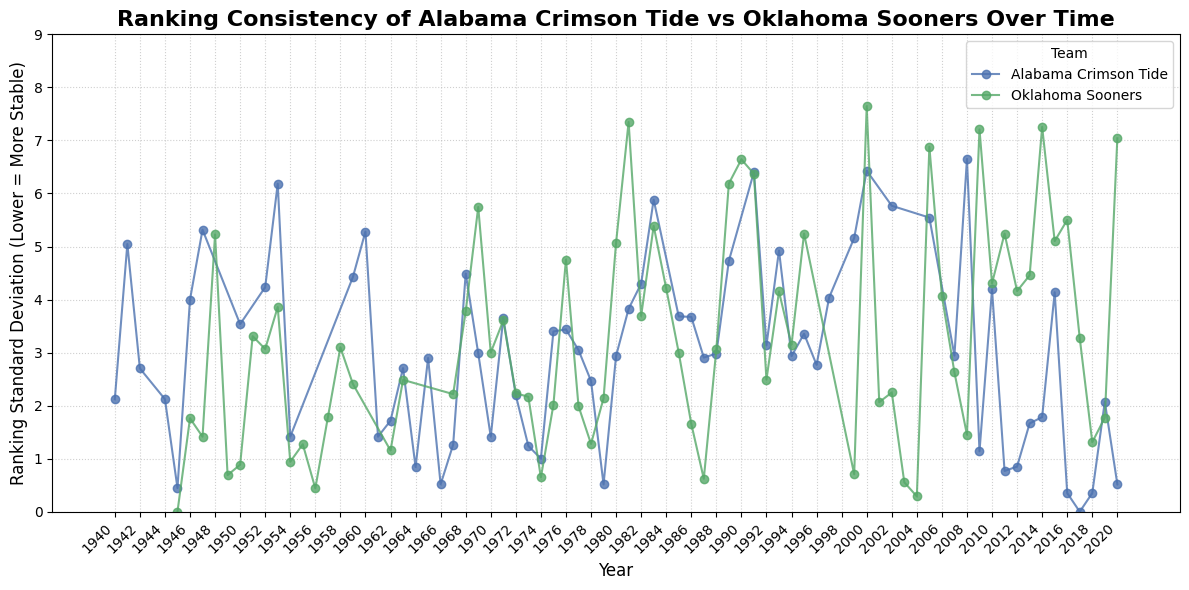

In [14]:
# Filter data to include only the top 2 teams for focused comparison
comparison_teams_df = ranking_stdev_df[ranking_stdev_df['team_name'].isin(top_2_team_names)]

start_year = 1940
end_year = 2020

# Filter the data frame to only include years between start_year and end_year (inclusive)
comparison_teams_df = comparison_teams_df[
    (comparison_teams_df['year'] >= start_year) & (comparison_teams_df['year'] <= end_year)
]

plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-deep')

# Plotting the time series for each team
for team in top_2_team_names:
    team_data = comparison_teams_df[comparison_teams_df['team_name'] == team]
    plt.plot(team_data['year'], team_data['ranking_stdev'], marker='o', linestyle='-', label=team, alpha=0.8)

# Adding labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ranking Standard Deviation (Lower = More Stable)', fontsize=12)
plt.title(f'Ranking Consistency of {top_2_team_names[0]} vs {top_2_team_names[1]} Over Time', fontsize=16, fontweight='bold')

# Add legend and grid
plt.legend(title='Team', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

margin = 5

# Set the limits of the x-axis to the range with margins
plt.xlim(start_year - margin, end_year + margin)

plt.xticks(np.arange(start_year, end_year + 1, 2), rotation=45, ha='right')

plt.ylim(ymin=0, ymax=9)
plt.tight_layout()
plt.show()